# Etapa 4 - Padroes Frequentes, Anomalias e Conclusoes

Nesta etapa usamos o arquivo `clusters_etapa3.csv`, gerado na Etapa 3, para complementar o projeto com:

- mineracao de padroes frequentes com Apriori;
- regras de associacao com suporte, confianca e lift;
- deteccao de anomalias por distancia aos vizinhos mais proximos;
- interpretacao dos clusters, implicacoes e limitacoes dos dados.

A etapa reaproveita a decisao da Etapa 3: K-Means com `K=4`, usando `Lat`, `Lon`, `Hour` e `Day`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

SEED = 42
COLUNAS_MODELO = ["Lat", "Lon", "Hour", "Day"]
MIN_SUPORTE = 0.08
MIN_CONFIANCA = 0.55
MIN_LIFT = 1.05
MAX_TAMANHO_ITEMSET = 3
K_VIZINHOS = 5
PERCENTIL_ANOMALIA = 0.975

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("Configuracao carregada.")


Configuracao carregada.


## 1. Carregamento dos dados

A entrada desta etapa e `etapa3/clusters_etapa3.csv`. Esse arquivo contem os dados tratados, os rotulos de cluster e as coordenadas originais para interpretacao espacial.


In [2]:
CAMINHOS_DADOS = [
    Path("../etapa3/clusters_etapa3.csv"),
    Path("etapa3/clusters_etapa3.csv"),
    Path("clusters_etapa3.csv"),
]

CAMINHO_DADOS = next((caminho for caminho in CAMINHOS_DADOS if caminho.exists()), None)
if CAMINHO_DADOS is None:
    raise FileNotFoundError("Arquivo 'clusters_etapa3.csv' nao encontrado. Execute a Etapa 3 antes.")

df = pd.read_csv(CAMINHO_DADOS)
df["Date/Time"] = pd.to_datetime(df["Date/Time"])
df["cluster_kmeans"] = df["cluster_kmeans"].astype(int)
df["Day"] = df["Day"].astype(int)

print("Arquivo carregado:", CAMINHO_DADOS)
print("Dimensao:", df.shape)
print("Valores ausentes:", int(df.isna().sum().sum()))
print("Bases distintas:", sorted(df["Base"].unique()))
display(df.head())


Arquivo carregado: ../etapa3/clusters_etapa3.csv
Dimensao: (19220, 9)
Valores ausentes: 0
Bases distintas: ['B02512']


,Date/Time,Base,Lat,Lon,Hour,Day,cluster_kmeans,Lat_original,Lon_original
0,2014-05-01 00:02:00,B02512,0.411657,0.280886,0.0,1,3,40.7521,-73.9914
1,2014-05-01 00:06:00,B02512,0.343719,0.289346,0.0,1,3,40.6965,-73.9715
2,2014-05-01 00:15:00,B02512,0.404692,0.284117,0.0,1,3,40.7464,-73.9838
3,2014-05-01 00:17:00,B02512,0.404570,0.276762,0.0,1,3,40.7463,-74.0011
4,2014-05-01 00:17:00,B02512,0.420577,0.288538,0.0,1,3,40.7594,-73.9734


## 2. Preparacao das categorias

Para minerar padroes frequentes, transformamos variaveis numericas em categorias simples:

- `Hour` vira periodo do dia;
- `Day` vira faixa de dias;
- latitude e longitude viram faixas por quartis;
- o rotulo `cluster_kmeans` entra como item da transacao.

A coluna `Base` nao entra na mineracao porque tem apenas um valor (`B02512`) em todos os registros.


In [3]:
df["hora"] = (df["Hour"] * 23).round().astype(int)
df["periodo"] = pd.cut(
    df["hora"],
    bins=[-1, 5, 11, 17, 23],
    labels=["madrugada", "manha", "tarde", "noite"],
)
df["faixa_dia"] = pd.cut(
    df["Day"],
    bins=[0, 5, 10, 16],
    labels=["01-05", "06-10", "11-16"],
)
df["faixa_lat"] = pd.qcut(
    df["Lat_original"],
    q=4,
    labels=["sul", "centro_sul", "centro_norte", "norte"],
)
df["faixa_lon"] = pd.qcut(
    df["Lon_original"],
    q=4,
    labels=["oeste", "centro_oeste", "centro_leste", "leste"],
)

categorias = df[["cluster_kmeans", "periodo", "faixa_dia", "faixa_lat", "faixa_lon"]].copy()
categorias["cluster_kmeans"] = "cluster=" + categorias["cluster_kmeans"].astype(str)
categorias["periodo"] = "periodo=" + categorias["periodo"].astype(str)
categorias["faixa_dia"] = "faixa_dia=" + categorias["faixa_dia"].astype(str)
categorias["faixa_lat"] = "latitude=" + categorias["faixa_lat"].astype(str)
categorias["faixa_lon"] = "longitude=" + categorias["faixa_lon"].astype(str)

print("Categorias criadas para Apriori:")
display(categorias.head())


Categorias criadas para Apriori:


,cluster_kmeans,periodo,faixa_dia,faixa_lat,faixa_lon
0,cluster=3,periodo=madrugada,faixa_dia=01-05,latitude=centro_norte,longitude=centro_oeste
1,cluster=3,periodo=madrugada,faixa_dia=01-05,latitude=sul,longitude=centro_leste
2,cluster=3,periodo=madrugada,faixa_dia=01-05,latitude=centro_sul,longitude=centro_leste
3,cluster=3,periodo=madrugada,faixa_dia=01-05,latitude=centro_sul,longitude=oeste
4,cluster=3,periodo=madrugada,faixa_dia=01-05,latitude=centro_norte,longitude=centro_leste


## 3. Perfil dos clusters

Antes dos padroes frequentes, resumimos os clusters para orientar a interpretacao.


In [4]:
perfil_clusters = (
    df.groupby("cluster_kmeans")
    .agg(
        registros=("cluster_kmeans", "size"),
        hora_media=("hora", "mean"),
        hora_pico=("hora", lambda s: s.mode().iloc[0]),
        dia_medio=("Day", "mean"),
        lat_media=("Lat_original", "mean"),
        lon_media=("Lon_original", "mean"),
        periodo_dominante=("periodo", lambda s: s.mode().iloc[0]),
    )
    .reset_index()
)
perfil_clusters["percentual"] = perfil_clusters["registros"] / len(df) * 100
perfil_clusters = perfil_clusters[
    ["cluster_kmeans", "registros", "percentual", "hora_media", "hora_pico", "dia_medio", "lat_media", "lon_media", "periodo_dominante"]
]

display(perfil_clusters.round(4))


,cluster_kmeans,registros,percentual,hora_media,hora_pico,dia_medio,lat_media,lon_media,periodo_dominante
0,0,6816,35.4631,16.7280,17,12.6602,40.7472,-73.9844,tarde
1,1,6590,34.2872,17.4091,17,4.3083,40.7474,-73.9870,tarde
2,2,589,3.0645,14.9559,18,8.0289,40.6681,-73.7765,noite
3,3,5225,27.1852,7.2498,7,8.0722,40.7507,-73.9830,manha


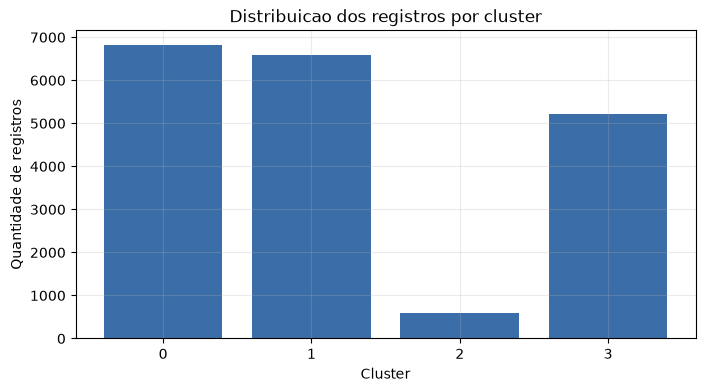

In [5]:
fig, eixo = plt.subplots(figsize=(8, 4))
eixo.bar(perfil_clusters["cluster_kmeans"].astype(str), perfil_clusters["registros"], color="#3b6ea8")
eixo.set_title("Distribuicao dos registros por cluster")
eixo.set_xlabel("Cluster")
eixo.set_ylabel("Quantidade de registros")
plt.show()


## 4. Mineracao de padroes frequentes com Apriori

Usamos Apriori porque ele e direto para bases transacionais pequenas e gera resultados interpretaveis. O suporte minimo escolhido foi 8%, para manter padroes relevantes sem listar combinacoes muito raras.


In [6]:
itens_unicos = sorted(pd.unique(categorias.to_numpy().ravel()))
transacoes = pd.DataFrame({
    item: categorias.eq(item).any(axis=1).to_numpy()
    for item in itens_unicos
})

itemsets = apriori(
    transacoes,
    min_support=MIN_SUPORTE,
    use_colnames=True,
    max_len=MAX_TAMANHO_ITEMSET,
)
itemsets["tamanho"] = itemsets["itemsets"].apply(len)
itemsets["itemset"] = itemsets["itemsets"].apply(lambda itens: " + ".join(sorted(itens)))
itemsets = itemsets.sort_values(["tamanho", "support", "itemset"], ascending=[False, False, True])

padroes_export = itemsets[["tamanho", "itemset", "support"]].rename(columns={"support": "suporte"})
padroes_export["suporte_percentual"] = padroes_export["suporte"] * 100

print("Quantidade de itemsets frequentes:", len(itemsets))
display(padroes_export.head(20).round(4))


Quantidade de itemsets frequentes: 88


,tamanho,itemset,suporte,suporte_percentual
85,3,cluster=0 + faixa_dia=11-16 + periodo=tarde,0.1332,13.3195
87,3,cluster=1 + faixa_dia=01-05 + periodo=tarde,0.1047,10.4735
86,3,cluster=1 + faixa_dia=01-05 + periodo=noite,0.1042,10.4162
84,3,cluster=0 + faixa_dia=11-16 + periodo=noite,0.0964,9.6410
18,2,cluster=0 + faixa_dia=11-16,0.2538,25.3798
28,2,cluster=1 + faixa_dia=01-05,0.2183,21.8314
39,2,cluster=3 + periodo=manha,0.1932,19.3236
27,2,cluster=0 + periodo=tarde,0.1819,18.1946
36,2,cluster=1 + periodo=tarde,0.1687,16.8678
35,2,cluster=1 + periodo=noite,0.1648,16.4776


## 5. Regras de associacao

As regras sao avaliadas por:

- **suporte:** frequencia do padrao na base;
- **confianca:** chance do consequente aparecer quando o antecedente aparece;
- **lift:** quanto a regra e mais forte do que uma associacao ao acaso.

Mantivemos regras com confianca minima de 55% e lift minimo de 1,05.


In [7]:
regras = association_rules(
    itemsets,
    num_itemsets=len(transacoes),
    metric="confidence",
    min_threshold=MIN_CONFIANCA,
)
regras = regras[regras["lift"] >= MIN_LIFT].copy()
regras["antecedente"] = regras["antecedents"].apply(lambda itens: " + ".join(sorted(itens)))
regras["consequente"] = regras["consequents"].apply(lambda itens: " + ".join(sorted(itens)))
regras = regras.sort_values(["lift", "confidence", "support"], ascending=[False, False, False])

regras_export = regras[["antecedente", "consequente", "support", "confidence", "lift"]].rename(
    columns={"support": "suporte", "confidence": "confianca"}
)

print("Quantidade de regras filtradas:", len(regras_export))
display(regras_export.head(15).round(4))


Quantidade de regras filtradas: 17


,antecedente,consequente,suporte,confianca,lift
13,periodo=manha,cluster=3,0.1932,0.8325,3.0625
12,cluster=3,periodo=manha,0.1932,0.7108,3.0625
2,faixa_dia=01-05 + periodo=tarde,cluster=1,0.1047,0.9549,2.7851
4,faixa_dia=01-05 + periodo=noite,cluster=1,0.1042,0.9538,2.7818
1,faixa_dia=11-16 + periodo=tarde,cluster=0,0.1332,0.9693,2.7334
7,faixa_dia=11-16 + periodo=noite,cluster=0,0.0964,0.9611,2.7101
14,latitude=norte,longitude=leste,0.1513,0.6099,2.4442
15,longitude=leste,latitude=norte,0.1513,0.6063,2.4442
16,longitude=centro_leste,latitude=centro_norte,0.1376,0.5507,2.1914
0,cluster=0 + periodo=tarde,faixa_dia=11-16,0.1332,0.7321,2.1325


In [8]:
def pasta_saida_etapa4():
    if Path.cwd().name == "etapa4":
        return Path(".")
    if Path("etapa4").exists():
        return Path("etapa4")
    return Path(".")

SAIDA = pasta_saida_etapa4()

caminho_padroes = SAIDA / "padroes_frequentes_etapa4.csv"
caminho_regras = SAIDA / "regras_associacao_etapa4.csv"
padroes_export.to_csv(caminho_padroes, index=False)
regras_export.to_csv(caminho_regras, index=False)

print("Padroes frequentes salvos em:", caminho_padroes)
print("Regras de associacao salvas em:", caminho_regras)


Padroes frequentes salvos em: padroes_frequentes_etapa4.csv
Regras de associacao salvas em: regras_associacao_etapa4.csv


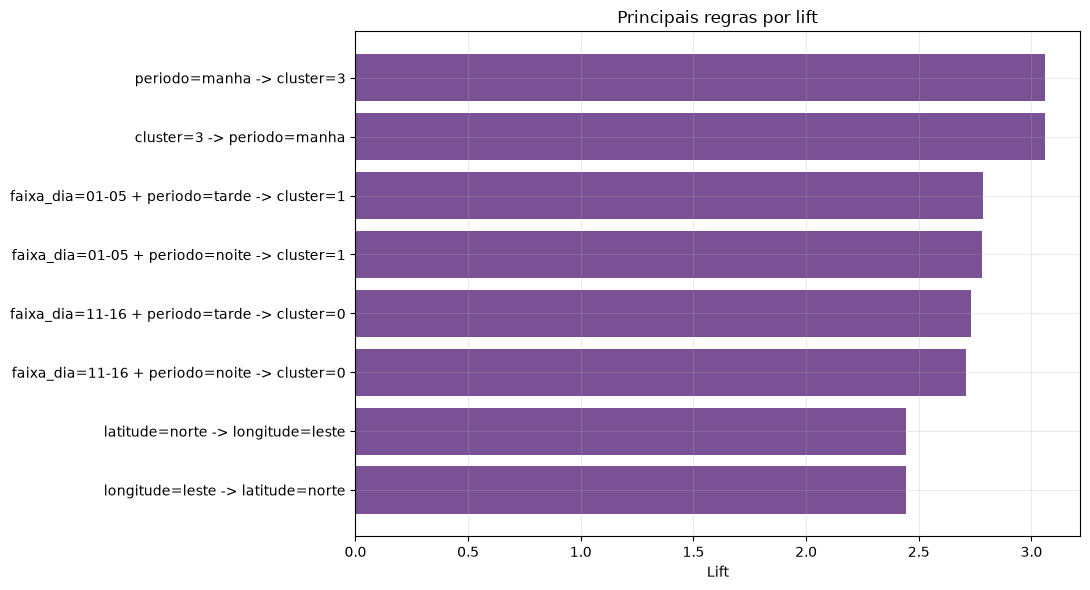

In [9]:
top_regras = regras_export.head(8).iloc[::-1]

fig, eixo = plt.subplots(figsize=(11, 6))
eixo.barh(
    top_regras["antecedente"] + " -> " + top_regras["consequente"],
    top_regras["lift"],
    color="#7a5195",
)
eixo.set_title("Principais regras por lift")
eixo.set_xlabel("Lift")
plt.tight_layout()
plt.show()


## 6. Deteccao de anomalias por distancia

A deteccao de anomalias usa o mesmo espaco numerico da clusterizacao: `Lat`, `Lon`, `Hour` e `Day`.

As variaveis sao padronizadas e, para cada registro, calculamos a distancia media aos 5 vizinhos mais proximos. Os pontos acima do percentil 97,5% dessa distancia sao marcados como anomalias.


In [10]:
X = df[COLUNAS_MODELO].astype(float)
X_padronizado = StandardScaler().fit_transform(X)

vizinhos = NearestNeighbors(n_neighbors=K_VIZINHOS + 1, metric="euclidean")
distancias, indices = vizinhos.fit(X_padronizado).kneighbors(X_padronizado)

df["distancia_media_5vizinhos"] = distancias[:, 1:].mean(axis=1)
limiar_anomalia = df["distancia_media_5vizinhos"].quantile(PERCENTIL_ANOMALIA)
df["anomalia_distancia"] = df["distancia_media_5vizinhos"] >= limiar_anomalia

print("Limiar de anomalia:", round(limiar_anomalia, 4))
print("Anomalias detectadas:", int(df["anomalia_distancia"].sum()))
print("Percentual de anomalias:", round(df["anomalia_distancia"].mean() * 100, 2), "%")


Limiar de anomalia: 0.7116
Anomalias detectadas: 481
Percentual de anomalias: 2.5 %


In [11]:
resumo_anomalias = (
    df.groupby("cluster_kmeans")
    .agg(
        registros=("cluster_kmeans", "size"),
        anomalias=("anomalia_distancia", "sum"),
    )
    .reset_index()
)
resumo_anomalias["percentual_no_cluster"] = resumo_anomalias["anomalias"] / resumo_anomalias["registros"] * 100

display(resumo_anomalias.round(4))

top_anomalias = df.sort_values("distancia_media_5vizinhos", ascending=False)[
    ["Date/Time", "cluster_kmeans", "hora", "Day", "Lat_original", "Lon_original", "distancia_media_5vizinhos"]
].head(10)

display(top_anomalias.round(4))


,cluster_kmeans,registros,anomalias,percentual_no_cluster
0,0,6816,81,1.1884
1,1,6590,90,1.3657
2,2,589,160,27.1647
3,3,5225,150,2.8708


/tmp/ipykernel_4472/4145490549.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_anomalias.round(4))


,Date/Time,cluster_kmeans,hora,Day,Lat_original,Lon_original,distancia_media_5vizinhos
4648,2014-05-04 18:42:00,2,18,4,40.9434,-72.2999,14.9760
8376,2014-05-08 01:35:00,3,1,8,40.4152,-74.1910,4.8229
2700,2014-05-02 23:42:00,1,23,2,41.2336,-73.6657,4.5069
11317,2014-05-09 23:27:00,1,23,9,40.5305,-74.5345,3.7265
4100,2014-05-04 06:04:00,3,6,4,40.4959,-74.4495,3.5815
439,2014-05-01 12:25:00,1,12,1,40.5906,-74.6521,3.4960
1797,2014-05-02 13:43:00,2,13,2,41.1780,-73.1872,3.2276
3792,2014-05-03 21:42:00,2,21,3,41.1871,-73.2658,3.1993
11355,2014-05-10 00:13:00,2,0,10,40.8721,-73.4288,3.0760
11382,2014-05-10 01:27:00,3,1,10,41.0954,-73.4218,2.9646


In [12]:
caminho_anomalias = SAIDA / "anomalias_etapa4.csv"
df.to_csv(caminho_anomalias, index=False)
print("Arquivo de anomalias salvo em:", caminho_anomalias)


Arquivo de anomalias salvo em: anomalias_etapa4.csv


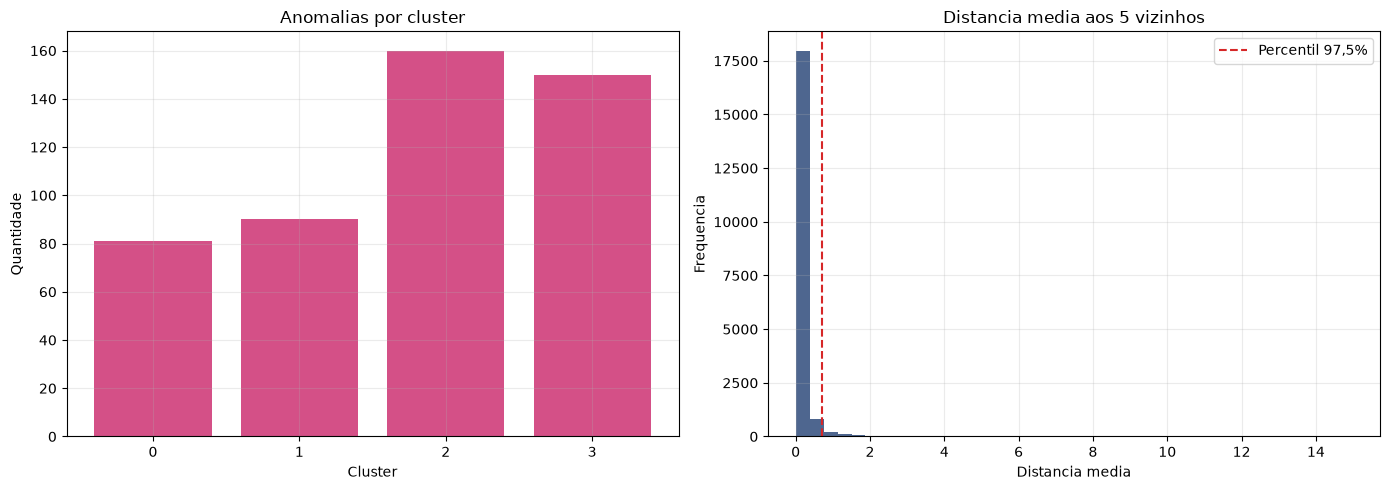

In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].bar(
    resumo_anomalias["cluster_kmeans"].astype(str),
    resumo_anomalias["anomalias"],
    color="#d45087",
)
eixos[0].set_title("Anomalias por cluster")
eixos[0].set_xlabel("Cluster")
eixos[0].set_ylabel("Quantidade")

eixos[1].hist(df["distancia_media_5vizinhos"], bins=40, color="#2f4b7c", alpha=0.85)
eixos[1].axvline(limiar_anomalia, color="#d62728", linestyle="--", label="Percentil 97,5%")
eixos[1].set_title("Distancia media aos 5 vizinhos")
eixos[1].set_xlabel("Distancia media")
eixos[1].set_ylabel("Frequencia")
eixos[1].legend()

plt.tight_layout()
plt.show()


## 7. Interpretacao e conclusoes

### Padroes observados

Os padroes frequentes mostram que os clusters capturam uma dimensao temporal forte:

- `periodo=manha -> cluster=3` tem alta confianca e lift superior a 3;
- `faixa_dia=01-05 + periodo=tarde/noite -> cluster=1` tem confianca acima de 95%;
- `faixa_dia=11-16 + periodo=tarde/noite -> cluster=0` tambem tem confianca acima de 96%.

Assim, os clusters nao representam apenas regioes do mapa. Eles combinam localizacao, horario e dia do periodo analisado.

### Relacao dos clusters com possiveis explicacoes

- **Cluster 0:** concentrado nos dias 11 a 16, principalmente tarde e noite.
- **Cluster 1:** concentrado nos dias 1 a 5, principalmente tarde e noite.
- **Cluster 2:** grupo pequeno, geograficamente mais afastado e com maior proporcao de anomalias.
- **Cluster 3:** fortemente associado ao periodo da manha, com pico entre 6h e 8h.

### Implicacoes e limitacoes

A analise sugere variacoes de demanda por horario e por periodo do mes, o que pode apoiar planejamento operacional. As limitacoes principais sao: apenas a base `B02512`, recorte de 1 a 16 de maio de 2014, ausencia de destinos/duracao das viagens e possibilidade de que anomalias sejam viagens reais para regioes distantes, nao erros.


## 8. Justificativas metodologicas

**Escolha das variaveis:** `Lat`, `Lon`, `Hour` e `Day` foram usadas porque representam a dimensao espaco-temporal da mobilidade. `Base` foi excluida da modelagem porque e constante no conjunto analisado.

**Escolha das metricas:** suporte, confianca e lift foram usados para padroes frequentes porque medem frequencia, forca condicional e ganho acima do acaso. Para anomalias, usamos distancia Euclidiana apos padronizacao, pois o objetivo era medir isolamento no mesmo espaco numerico usado nos clusters.

**Escolha dos algoritmos:** Apriori foi escolhido por ser simples e interpretavel para transacoes categoricas. A deteccao por distancia aos vizinhos foi escolhida por atender diretamente ao pedido de outliers por distancia.

**Escolha do numero de clusters:** a Etapa 4 manteve `K=4`, definido na Etapa 3 com base em silhouette, Davies-Bouldin, Calinski-Harabasz, estabilidade entre sementes e simplicidade interpretativa.
